In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

In [2]:
GSEA_FOLDER = "gsea_results_celltype_merged"
FILE_GLOB = "*.csv"

# Which enrichment score to use as the program->pathway embedding
SCORE_COL = "NES"

# Optional: keep only significant pathways
USE_FDR_FILTER = False
FDR_CUTOFF = 0.25

# Similarity settings: "pearson" or "cosine" or "spearman"
SIMILARITY = "spearman"

# Hierarchy logic:
HI_THRESH = 0.90      # if best similarity >= HI_THRESH -> single green edge
MAX_PARENTS = 3       # if best similarity < HI_THRESH -> keep top 3 parents
MIN_SIM = None        # optional: drop edges below this (only applies in multi-parent case)

K_MIN = None
K_MAX = 10

# Output
OUT_EDGES_CSV = "gep_tree_edges_from_gsea.csv"

In [3]:
def load_gsea_folder(folder: str, file_glob="*.csv") -> pd.DataFrame:
    folder = Path(folder)
    files = sorted(folder.glob(file_glob))
    if not files:
        raise FileNotFoundError(f"No files matched {file_glob} in {folder}")

    dfs = []
    for fp in files:
        if fp.suffix.lower() in [".csv", ".tsv", ".txt"]:
            df = pd.read_csv(fp)
        elif fp.suffix.lower() in [".xlsx", ".xls"]:
            df = pd.read_excel(fp)
        else:
            raise ValueError(f"Unsupported file type: {fp}")

        df["__source_file__"] = fp.name
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    return out

gsea_all = load_gsea_folder(GSEA_FOLDER, FILE_GLOB)
print("Loaded rows:", len(gsea_all))
print("Columns:", list(gsea_all.columns))
gsea_all.head()

Loaded rows: 209508
Columns: ['K', 'GEP', 'pathway', 'NES', 'pval', 'fdr', 'Name', 'ES', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes', 'spectra_file', '__source_file__']


,K,GEP,pathway,NES,pval,fdr,Name,ES,FWER p-val,Tag %,Gene %,Lead_genes,spectra_file,__source_file__
0,10,1,MERGED_BRAIN_IMMUNE,-3.354363,0.0,0.0,prerank,-0.774997,0.0,73/97,11.14%,ARHGEF1;AKNA;CD74;IL2RG;CORO1A;ACAP1;ARHGAP15;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
1,10,1,MERGED_CI_MESENCHYMAL,-3.269914,0.0,0.0,prerank,-0.635208,0.0,179/261,18.12%,LAPTM5;CORO1A;ACAP1;ARHGAP15;TMC8;WIPF1;ITGAL;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
2,10,1,MERGED_B_T,-3.221652,0.0,0.0,prerank,-0.743866,0.0,106/123,21.24%,ARHGEF1;LAPTM5;IL2RG;CORO1A;ACAP1;ARHGAP15;TMC...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
3,10,1,MERGED_BRAIN_EFFECTOR_T,-3.023871,0.0,0.0,prerank,-0.678600,0.0,80/105,22.86%,AKNA;IL2RG;CORO1A;ACAP1;ITGAL;ADGRE5;RAC2;SEPT...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
4,10,1,MERGED_BRAIN_B,-2.918104,0.0,0.0,prerank,-0.730472,0.0,51/64,16.46%,ATP2A3;CD74;IL2RG;CORO1A;ACAP1;ARHGAP15;RAC2;L...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv


In [4]:
gsea_all = gsea_all.drop(columns=['Name'])
gsea_all.head()

,K,GEP,pathway,NES,pval,fdr,ES,FWER p-val,Tag %,Gene %,Lead_genes,spectra_file,__source_file__
0,10,1,MERGED_BRAIN_IMMUNE,-3.354363,0.0,0.0,-0.774997,0.0,73/97,11.14%,ARHGEF1;AKNA;CD74;IL2RG;CORO1A;ACAP1;ARHGAP15;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
1,10,1,MERGED_CI_MESENCHYMAL,-3.269914,0.0,0.0,-0.635208,0.0,179/261,18.12%,LAPTM5;CORO1A;ACAP1;ARHGAP15;TMC8;WIPF1;ITGAL;...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
2,10,1,MERGED_B_T,-3.221652,0.0,0.0,-0.743866,0.0,106/123,21.24%,ARHGEF1;LAPTM5;IL2RG;CORO1A;ACAP1;ARHGAP15;TMC...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
3,10,1,MERGED_BRAIN_EFFECTOR_T,-3.023871,0.0,0.0,-0.678600,0.0,80/105,22.86%,AKNA;IL2RG;CORO1A;ACAP1;ITGAL;ADGRE5;RAC2;SEPT...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv
4,10,1,MERGED_BRAIN_B,-2.918104,0.0,0.0,-0.730472,0.0,51/64,16.46%,ATP2A3;CD74;IL2RG;CORO1A;ACAP1;ARHGAP15;RAC2;L...,anal_pc5_c21_S1.filtered.gene_spectra_score.k_...,K10_celltype_gsea.csv


In [5]:
# gsea_use = gsea_all.copy()

# if USE_FDR_FILTER:
#     if "fdr" not in gsea_use.columns:
#         raise ValueError("USE_FDR_FILTER=True but no 'fdr' column found in your GSEA tables.")
#     gsea_use = gsea_use[pd.to_numeric(gsea_use["fdr"], errors="coerce") <= FDR_CUTOFF].copy()

# print("Rows after FDR filter:", len(gsea_use))
# gsea_use.head()

In [6]:
def build_k_to_matrix(df: pd.DataFrame, score_col="NES") -> dict[int, pd.DataFrame]:
    df = df.copy()

    # Unique program id (so program names don't collide across K)
    df["program_id"] = df.apply(lambda r: f"K{int(r['K'])}_GEP{int(r['GEP'])}", axis=1)

    k_to_mat = {}
    for k, sub in df.groupby("K"):
        mat = sub.pivot_table(
            index="program_id",
            columns="pathway",
            values=score_col,
            aggfunc="max"
        )
        mat = mat.fillna(0.0)
        k_to_mat[int(k)] = mat

    return k_to_mat

k_to_mat = build_k_to_matrix(gsea_all, score_col=SCORE_COL)

print("Built matrices for Ks:", sorted(k_to_mat.keys())[:10], "..." )
some_k = sorted(k_to_mat.keys())[0]
print("Example K:", some_k, "shape:", k_to_mat[some_k].shape)
k_to_mat[some_k].iloc[:5, :5]

Built matrices for Ks: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14] ...
Example K: 5 shape: (5, 474)


pathway,MERGED_0_CAP_MESENCHYME,MERGED_10_IMMUNE,MERGED_1_EMBRYONIC_RED_BLOOD,MERGED_2_NEPHRON_PROGENITOR,MERGED_3_STROMAL
program_id,,,,,
K5_GEP1,-1.720223,1.634715,-1.888042,-1.855728,-2.592682
K5_GEP2,1.937435,-2.170203,1.769800,1.588957,1.540787
K5_GEP3,-1.859612,-1.888607,-0.861166,1.519782,-2.218034
K5_GEP4,1.025985,-1.743047,-1.528695,-1.125802,2.094263
K5_GEP5,-1.571330,1.994816,-0.851342,-1.613644,-1.347265


In [7]:
all_ks = sorted(k_to_mat.keys())
kmin = K_MIN if K_MIN is not None else min(all_ks)
kmax = K_MAX if K_MAX is not None else max(all_ks)

k_chain = [k for k in range(kmin, kmax + 1) if k in k_to_mat]
print("Using K chain:", k_chain)

Using K chain: [5, 6, 7, 8, 9, 10]


In [8]:
def cosine_similarity_matrix(B: np.ndarray, A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Returns C = cosine similarity between each row of B and each row of A.
    Output shape: (B_rows, A_rows).
    """
    A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + eps)
    B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + eps)
    return B_norm @ A_norm.T

def pearson_similarity_matrix(B: np.ndarray, A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """
    Pearson correlation between rows of B and rows of A.
    Output shape: (B_rows, A_rows).
    """
    A0 = A - A.mean(axis=1, keepdims=True)
    B0 = B - B.mean(axis=1, keepdims=True)

    A_den = np.linalg.norm(A0, axis=1, keepdims=True) + eps
    B_den = np.linalg.norm(B0, axis=1, keepdims=True) + eps

    A1 = A0 / A_den
    B1 = B0 / B_den
    return B1 @ A1.T

def _rank_rows_dense(X: np.ndarray) -> np.ndarray:
    """
    Dense ranks per row (ties get same rank). Uses pandas for robust tie handling.
    """
    return pd.DataFrame(X).rank(axis=1, method="dense").to_numpy(dtype=float)

def spearman_similarity_matrix(B: np.ndarray, A: np.ndarray) -> np.ndarray:
    """
    Spearman correlation = Pearson correlation of per-row ranks.
    Output shape: (B_rows, A_rows).
    """
    Br = _rank_rows_dense(B)
    Ar = _rank_rows_dense(A)
    return pearson_similarity_matrix(Br, Ar)

def similarity_matrix(df_child: pd.DataFrame, df_parent: pd.DataFrame, method="pearson") -> pd.DataFrame:
    # align pathway columns
    common = df_child.columns.intersection(df_parent.columns)
    if len(common) == 0:
        raise ValueError("No overlapping pathway columns between child and parent matrices.")

    B = df_child[common].to_numpy(dtype=float)
    A = df_parent[common].to_numpy(dtype=float)

    method = method.lower().strip()
    if method == "cosine":
        C = cosine_similarity_matrix(B, A)
    elif method == "pearson":
        C = pearson_similarity_matrix(B, A)
    elif method == "spearman":
        C = spearman_similarity_matrix(B, A)
    else:
        raise ValueError("method must be one of: 'pearson', 'cosine', 'spearman'")

    return pd.DataFrame(C, index=df_child.index, columns=df_parent.index)

print("Similarity method:", SIMILARITY)

Similarity method: spearman


In [9]:
def build_tree_edges_multi(
    k_to_mat: dict[int, pd.DataFrame],
    k_chain: list[int],
    sim_method: str = "pearson",
    hi_thresh: float = 0.90,
    max_parents: int = 3,
    min_sim=None,
    low_rank_colors=("purple", "red", "pink"),
    hi_color="green",
) -> pd.DataFrame:
    """
    For each child program at K+1:
      - if best similarity >= hi_thresh: connect ONLY best parent, color green
      - else: connect top `max_parents` parents, color purple/red/pink by rank
    """
    edges = []

    for k in k_chain[:-1]:
        if (k not in k_to_mat) or (k + 1 not in k_to_mat):
            continue

        parent = k_to_mat[k]
        child  = k_to_mat[k + 1]

        sim = similarity_matrix(child, parent, method=sim_method)  # rows=child, cols=parent

        for child_id, row in sim.iterrows():
            row_sorted = row.sort_values(ascending=False)

            best_parent = row_sorted.index[0]
            best_sim = float(row_sorted.iloc[0])

            if best_sim >= hi_thresh:
                edges.append({
                    "parent_k": k,
                    "child_k": k + 1,
                    "parent_id": best_parent,
                    "child_id": child_id,
                    "similarity": best_sim,
                    "rank": 1,
                    "color": hi_color,
                    "mode": "high"
                })
            else:
                top = row_sorted.head(max_parents)

                # optional filter only for multi-parent case
                if min_sim is not None:
                    top = top[top >= float(min_sim)]
                    if top.empty:
                        top = row_sorted.head(1)

                for rnk, (pid, sval) in enumerate(top.items(), start=1):
                    color = low_rank_colors[rnk - 1] if rnk <= len(low_rank_colors) else low_rank_colors[-1]
                    edges.append({
                        "parent_k": k,
                        "child_k": k + 1,
                        "parent_id": pid,
                        "child_id": child_id,
                        "similarity": float(sval),
                        "rank": rnk,
                        "color": color,
                        "mode": "low"
                    })

    return pd.DataFrame(edges)

edges_df = build_tree_edges_multi(
    k_to_mat=k_to_mat,
    k_chain=k_chain,
    sim_method=SIMILARITY,
    hi_thresh=HI_THRESH,
    max_parents=MAX_PARENTS,
    min_sim=MIN_SIM
)

print("Edges:", len(edges_df))
edges_df.head(10)

Edges: 52


,parent_k,child_k,parent_id,child_id,similarity,rank,color,mode
0,5,6,K5_GEP1,K6_GEP1,0.999319,1,green,high
1,5,6,K5_GEP2,K6_GEP2,0.992479,1,green,high
2,5,6,K5_GEP3,K6_GEP3,0.998335,1,green,high
3,5,6,K5_GEP4,K6_GEP4,0.995757,1,green,high
4,5,6,K5_GEP5,K6_GEP5,0.997237,1,green,high
5,5,6,K5_GEP3,K6_GEP6,0.463958,1,purple,low
6,5,6,K5_GEP5,K6_GEP6,0.222738,2,red,low
7,5,6,K5_GEP4,K6_GEP6,-0.013862,3,pink,low
8,6,7,K6_GEP2,K7_GEP1,0.995868,1,green,high
9,6,7,K6_GEP1,K7_GEP2,0.931961,1,green,high


In [10]:
if len(edges_df) == 0:
    print("No edges built. Common causes: no overlapping pathways across K, or MIN_SIM too high.")
else:
    # Now children CAN have >1 parent when best < HI_THRESH
    vc = edges_df["child_id"].value_counts()
    print("Children with 1 edge:", int((vc == 1).sum()))
    print("Children with 2 edges:", int((vc == 2).sum()))
    print("Children with 3+ edges:", int((vc >= 3).sum()))
    print("Total children connected:", int(vc.shape[0]))

    edges_df.to_csv(OUT_EDGES_CSV, index=False)
    print("Wrote:", OUT_EDGES_CSV)


Children with 1 edge: 34
Children with 2 edges: 0
Children with 3+ edges: 6
Total children connected: 40
Wrote: gep_tree_edges_from_gsea.csv


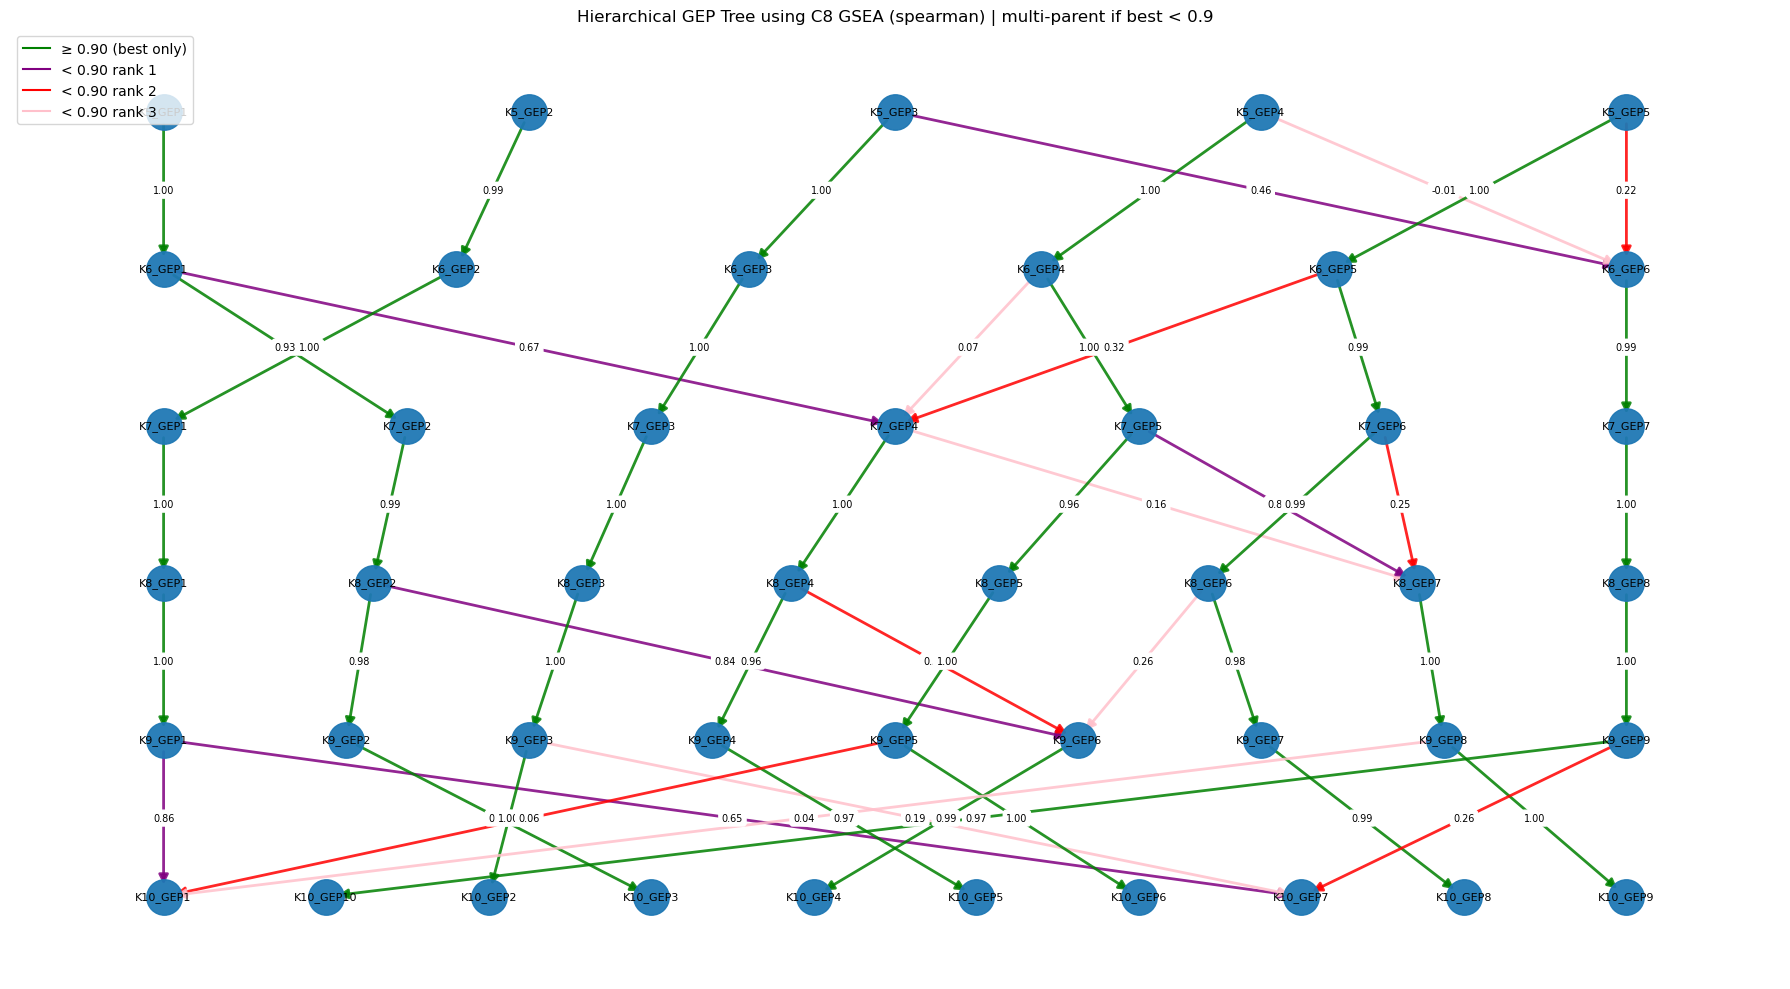

In [11]:
def plot_tree(edges_df: pd.DataFrame, title: str, figsize=(18, 10)):
    if edges_df is None or len(edges_df) == 0:
        print("No edges to plot.")
        return

    G = nx.DiGraph()

    # Add nodes with level attribute (K)
    for _, e in edges_df.iterrows():
        G.add_node(e["parent_id"], level=int(e["parent_k"]))
        G.add_node(e["child_id"],  level=int(e["child_k"]))

        # DiGraph doesn't support true parallel edges; rank makes edges unique conceptually,
        # but we'll still add them normally (many will share same u->v only if ties).
        G.add_edge(
            e["parent_id"], e["child_id"],
            similarity=float(e["similarity"]),
            color=e["color"],
            rank=int(e["rank"])
        )

    # Build a top-down layout: group by level (K)
    levels = {}
    for n, d in G.nodes(data=True):
        levels.setdefault(d["level"], []).append(n)
    for k in levels:
        levels[k] = sorted(levels[k])

    sorted_levels = sorted(levels.keys())
    pos = {}
    for li, k in enumerate(sorted_levels):
        nodes = levels[k]
        xs = [0.5] if len(nodes) == 1 else np.linspace(0.05, 0.95, len(nodes))
        y = -li
        for x, n in zip(xs, nodes):
            pos[n] = (float(x), float(y))

    plt.figure(figsize=figsize)
    ax = plt.gca()
    ax.set_title(title)

    nx.draw_networkx_nodes(G, pos, node_size=650, alpha=0.95)
    nx.draw_networkx_labels(G, pos, font_size=8)

    edgelist = list(G.edges())
    edge_colors = [G.edges[u, v]["color"] for u, v in edgelist]
    nx.draw_networkx_edges(
        G, pos,
        edgelist=edgelist,
        edge_color=edge_colors,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=14,
        width=2.0,
        alpha=0.85
    )

    edge_labels = {(u, v): f'{G.edges[u, v]["similarity"]:.2f}' for u, v in edgelist}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, rotate=False)

    # Legend
    import matplotlib.lines as mlines
    handles = [
        mlines.Line2D([], [], color="green",  label=f"≥ {HI_THRESH:.2f} (best only)"),
        mlines.Line2D([], [], color="purple", label=f"< {HI_THRESH:.2f} rank 1"),
        mlines.Line2D([], [], color="red",    label=f"< {HI_THRESH:.2f} rank 2"),
        mlines.Line2D([], [], color="pink",   label=f"< {HI_THRESH:.2f} rank 3"),
    ]
    ax.legend(handles=handles, loc="upper left", frameon=True)

    ax.axis("off")
    plt.tight_layout()
    plt.show()

plot_tree(
    edges_df,
    title=f"Hierarchical GEP Tree using C8 GSEA ({SIMILARITY}) | multi-parent if best < {HI_THRESH}"
)


In [14]:
# --- Build a clustree-ready table: rows=pathways, columns=K5..K10 (or whatever k_chain is) ---
import re
import numpy as np
import pandas as pd

OUT_CLUSTREE_CSV = "clustree_export_R_proj/clustree_input_pathways_by_bestGEP.csv"

def _extract_gep_int(program_id: str) -> int:
    """
    program_id looks like 'K7_GEP12' (built earlier in your notebook).
    Return 12 as an int.
    """
    m = re.search(r"_GEP(\d+)$", str(program_id))
    return int(m.group(1)) if m else np.nan

# Union of pathways across the K's you're using
all_pathways = sorted(set().union(*[set(k_to_mat[k].columns) for k in k_chain]))

clustree_df = pd.DataFrame({"pathway": all_pathways}).set_index("pathway")

for k in k_chain:
    mat = k_to_mat[k]  # rows=program_id, cols=pathway, values=NES (or SCORE_COL)
    # For each pathway, pick the program_id (row) with max score
    best_program = mat.idxmax(axis=0)  # index=pathway, value=program_id
    # Convert K?_GEP? -> integer cluster id for clustree
    clustree_df[f"K{k}"] = best_program.map(_extract_gep_int).astype("Int64")

# Optional sanity checks
print("clustree_df shape:", clustree_df.shape)
print("K columns:", [c for c in clustree_df.columns if c.startswith("K")])
print(clustree_df.head())

clustree_df.to_csv(OUT_CLUSTREE_CSV)
print("Wrote:", OUT_CLUSTREE_CSV)


clustree_df shape: (474, 6)
K columns: ['K5', 'K6', 'K7', 'K8', 'K9', 'K10']
                              K5  K6  K7  K8  K9  K10
pathway                                              
MERGED_0_CAP_MESENCHYME        2   2   1   1   1    1
MERGED_10_IMMUNE               5   5   6   6   7    8
MERGED_1_EMBRYONIC_RED_BLOOD   2   2   1   1   1    1
MERGED_2_NEPHRON_PROGENITOR    2   2   1   1   1    1
MERGED_3_STROMAL               4   4   5   5   5    6
Wrote: clustree_export_R_proj/clustree_input_pathways_by_bestGEP.csv
